# 🚦 Análisis Exploratorio de Datos (EDA): Accidentalidad en NY
En este cuaderno documentaremos el proceso paso a paso para limpiar, transformar y analizar los datos de accidentes vehiculares en Nueva York, cruzándolos con información meteorológica.

## 1. Carga de los conjuntos de datos en bruto
Importamos las librerías necesarias y cargamos nuestros datos crudos.
Agregamos `low_memory=False` porque son archivos grandes y Pandas lo recomienda.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargamos los conjuntos de datos en bruto
df_clima = pd.read_csv('72505394728.csv', low_memory=False)
df_accidentes = pd.read_csv('Motor_Vehicle_Collisions_-_Crashes_20260906.csv', low_memory=False)

# Verificamos el tamaño de cada tabla (filas, columnas)
print("Tamaño tabla Clima:", df_clima.shape)
print("Tamaño tabla Accidentes:", df_accidentes.shape)

Tamaño tabla Clima: (11590, 91)
Tamaño tabla Accidentes: (91069, 29)


## 2. Análisis de la Fuente de Datos: Clima
Revisamos la estructura técnica de la tabla

In [11]:
# Analizamos el contenido de nuestra fuente de datos
df_clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 11590 entries, 0 to 11589
Data columns (total 91 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATION          11590 non-null  int64  
 1   DATE             11590 non-null  str    
 2   SOURCE           11590 non-null  int64  
 3   LATITUDE         11590 non-null  float64
 4   LONGITUDE        11590 non-null  float64
 5   ELEVATION        11590 non-null  float64
 6   NAME             11590 non-null  str    
 7   REPORT_TYPE      11590 non-null  str    
 8   CALL_SIGN        11590 non-null  str    
 9   QUALITY_CONTROL  11590 non-null  str    
 10  WND              11590 non-null  str    
 11  CIG              11590 non-null  str    
 12  VIS              11590 non-null  str    
 13  TMP              11590 non-null  str    
 14  DEW              11590 non-null  str    
 15  SLP              11590 non-null  str    
 16  AA1              10272 non-null  str    
 17  AA2              631 no

### Hallazgos

* **Eliminación de columnas irrelevantes:** Identificamos que variables como `AA3` y `AB1` tienen muy pocos datos válidos de los **11,590 registros totales**, por lo que no aportan valor al análisis. 
* **Estrategia de filtrado:** En lugar de removerlas individualmente con `.drop()` (lo cual sería ineficiente debido a la gran cantidad de nombres), la mejor práctica es aplicar un filtro inverso: **seleccionar y conservar únicamente las columnas útiles**.


In [16]:
# Filtramos el DataFrame para quedarnos solo con las columnas esenciales, y sobreescribimos la antigua
df_clima = df_clima[['DATE', 'LATITUDE', 'LONGITUDE', 'WND', 'VIS', 'TMP', 'AA1']]

# Vemos el resumen de lo que nos quedó
df_clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 11590 entries, 0 to 11589
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DATE       11590 non-null  str    
 1   LATITUDE   11590 non-null  float64
 2   LONGITUDE  11590 non-null  float64
 3   WND        11590 non-null  str    
 4   VIS        11590 non-null  str    
 5   TMP        11590 non-null  str    
 6   AA1        11590 non-null  object 
dtypes: float64(2), object(1), str(4)
memory usage: 634.0+ KB


Podemos analizar que todas las columnas a excepción de AA1 (10272) tienen un total de 11590 filas, con lo cual debemos analizarla y ver exactamente cuántos nulos hay.

In [17]:
# Contamos cuántos valores nulos hay exactamente en cada columna
print(df_clima.isnull().sum())

DATE         0
LATITUDE     0
LONGITUDE    0
WND          0
VIS          0
TMP          0
AA1          0
dtype: int64


Tenemos exactamente 1318 valores nulos en la columna AA1 que es la de precipitación, entonces hay que decirle a Pandas que donde falten datos asuma que llovió “0” y los llene.

In [18]:
# Rellenamos valores nulos de la columna AA1 con 0
df_clima['AA1'] = df_clima['AA1'].fillna(0)

# Validamos luego del llenado
print(df_clima.isnull().sum())

DATE         0
LATITUDE     0
LONGITUDE    0
WND          0
VIS          0
TMP          0
AA1          0
dtype: int64


Podemos ver que ya no tenemos nulos.

Ahora podemos continuar analizando la segunda fuente de datos.

## 3. Análisis de la Fuente de Datos: Accidentes
Realizamos el mismo proceso de exploración.

Revisamos la estructura técnica de la tabla

In [19]:
# Analizamos el contenido de nuestra fuente de datos
df_accidentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 91069 entries, 0 to 91068
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     91069 non-null  str    
 1   CRASH TIME                     91069 non-null  str    
 2   BOROUGH                        65071 non-null  str    
 3   ZIP CODE                       65057 non-null  float64
 4   LATITUDE                       83996 non-null  str    
 5   LONGITUDE                      83996 non-null  str    
 6   LOCATION                       83996 non-null  str    
 7   ON STREET NAME                 65252 non-null  str    
 8   CROSS STREET NAME              47039 non-null  str    
 9   OFF STREET NAME                25817 non-null  str    
 10  NUMBER OF PERSONS INJURED      91069 non-null  int64  
 11  NUMBER OF PERSONS KILLED       91069 non-null  int64  
 12  NUMBER OF PEDESTRIANS INJURED  91069 non-null  int64  
 1

### Conclusiones del Diagnóstico de Datos

Tras el análisis del conjunto de datos, identificamos tres puntos clave:

* **Columnas completas:** Variables críticas como `CRASH DATE`, `CRASH TIME` y `NUMBER OF PERSONS INJURED / KILLED` están totalmente completas con **91,069 registros**.
* **Columnas vacías con lógica:** Columnas secundarias como `CONTRIBUTING FACTOR VEHICLE 3, 4 y 5` o `VEHICLE TYPE CODE 3, 4 y 5` están prácticamente vacías. Esto tiene sentido lógico, ya que la mayoría de los accidentes involucran solo 1 o 2 vehículos y rara vez llegan a 5.
* **Reducción de dimensiones:** No necesitamos las 29 columnas originales del dataset. Por lo tanto, realizaremos una limpieza para conservar únicamente las variables que aportan valor real al análisis.


In [53]:
# Filtramos el DataFrame para quedarnos solo con las columnas esenciales, y sobreescribimos la antigua
df_accidentes = df_accidentes[[
    'CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'ON STREET NAME', 'CROSS STREET NAME', 'LATITUDE', 'LONGITUDE',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
    'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1'
]]

# Vemos el resumen de lo que nos quedó
df_accidentes.info()

<class 'pandas.DataFrame'>
Index: 83996 entries, 0 to 91068
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   CRASH DATE                     83996 non-null  str   
 1   CRASH TIME                     83996 non-null  str   
 2   BOROUGH                        83996 non-null  str   
 3   ZIP CODE                       83996 non-null  object
 4   ON STREET NAME                 83996 non-null  str   
 5   CROSS STREET NAME              83996 non-null  str   
 6   LATITUDE                       83996 non-null  str   
 7   LONGITUDE                      83996 non-null  str   
 8   NUMBER OF PERSONS INJURED      83996 non-null  int64 
 9   NUMBER OF PERSONS KILLED       83996 non-null  int64 
 10  NUMBER OF PEDESTRIANS INJURED  83996 non-null  int64 
 11  NUMBER OF CYCLIST INJURED      83996 non-null  int64 
 12  CONTRIBUTING FACTOR VEHICLE 1  83996 non-null  str   
 13  VEHICLE TYPE CODE

### Resumen del Estado del Dataset

Tras las primeras modificaciones, el estado actual del conjunto de datos es el siguiente:

* **Optimización de memoria:** Logramos reducir el peso del archivo en memoria de **20.1 MB** a solo **9.7 MB**.
* **Identificación de datos faltantes:** Detectamos que varias variables clave no alcanzan el total de **91,069 registros**. Entre ellas se encuentran `BOROUGH`, `ON STREET NAME`, `LATITUDE`, `LONGITUDE`, `CONTRIBUTING FACTOR VEHICLE 1` y `VEHICLE TYPE CODE 1`. 
* **Inconsistencia de tipos:** Cabe destacar que Pandas clasificó la variable `ZIP CODE` como `float64` debido a la presencia de estos mismos valores nulos.

> *A continuación, analizaremos exactamente cuántos registros vacíos ("huecos") debemos limpiar en cada una de las variables mencionadas:*


In [54]:
# Contamos cuántos valores nulos hay exactamente en nuestra nueva tabla
print(df_accidentes.isnull().sum()) 

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
ON STREET NAME                   0
CROSS STREET NAME                0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF CYCLIST INJURED        0
CONTRIBUTING FACTOR VEHICLE 1    0
VEHICLE TYPE CODE 1              0
dtype: int64


Según lo analizado vemos que hay dos grandes tipos de datos:

* **Variables de texto:** Incluye 'BOROUGH', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1', 'ZIP CODE', 'ON STREET NAME' y 'CROSS STREET NAME'. No se pueden usar fórmulas matemáticas ni promedios, pero tampoco se debe borrar la información. Lo ideal es llenar estos valores vacíos con la etiqueta "UNSPECIFIED" (No especificado). Así conservamos la fila y, al analizar la información, se mostrará que el dato no fue reportado.
* **Variables de coordenadas:** Faltan aproximadamente 7,073 datos. Si eliminamos estas filas, la tabla bajaría de 91,069 a 84,000 registros. Como esto no afecta significativamente la muestra, los borraremos para quedarnos únicamente con los accidentes que se pueden ubicar en un mapa.


In [55]:
# Limpieza de las columnas de datos
# Rellenamos los nulos de las columnas de texto con 'UNSPECIFIED'
columnas_texto = ['BOROUGH', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1', 'ZIP CODE', 'ON STREET NAME', 'CROSS STREET NAME']
df_accidentes[columnas_texto] = df_accidentes[columnas_texto].fillna('UNSPECIFIED')

# Eliminamos las filas que no tienen coordenadas (borra la fila completa si falta latitud o longitud)
df_accidentes = df_accidentes.dropna(subset=['LATITUDE', 'LONGITUDE'])

# Imprimimos de nuevo para verificar que todo quedó en cero
print("Nulos después de la limpieza:")
print(df_accidentes.isnull().sum())


Nulos después de la limpieza:
CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
ON STREET NAME                   0
CROSS STREET NAME                0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF CYCLIST INJURED        0
CONTRIBUTING FACTOR VEHICLE 1    0
VEHICLE TYPE CODE 1              0
dtype: int64


### Validación

* **Confirmación de limpieza:** Según los pasos anteriores, comprobamos que se han eliminado o imputado todos los valores nulos del conjunto de datos.
* **Control de calidad:** Sin embargo, ejecutaremos el método `.info()` una vez más para validar rigurosamente la estructura final, los tipos de datos y asegurar que no existan inconsistencias.


In [56]:
# Consultamos información de nuestra nueva tabla
df_accidentes.info()

<class 'pandas.DataFrame'>
Index: 83996 entries, 0 to 91068
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   CRASH DATE                     83996 non-null  str   
 1   CRASH TIME                     83996 non-null  str   
 2   BOROUGH                        83996 non-null  str   
 3   ZIP CODE                       83996 non-null  object
 4   ON STREET NAME                 83996 non-null  str   
 5   CROSS STREET NAME              83996 non-null  str   
 6   LATITUDE                       83996 non-null  str   
 7   LONGITUDE                      83996 non-null  str   
 8   NUMBER OF PERSONS INJURED      83996 non-null  int64 
 9   NUMBER OF PERSONS KILLED       83996 non-null  int64 
 10  NUMBER OF PEDESTRIANS INJURED  83996 non-null  int64 
 11  NUMBER OF CYCLIST INJURED      83996 non-null  int64 
 12  CONTRIBUTING FACTOR VEHICLE 1  83996 non-null  str   
 13  VEHICLE TYPE CODE

### Preparación para el Cruce de Información

Una vez confirmado que el conjunto de datos está **libre de valores nulos**, el siguiente paso es garantizar la consistencia de las variables para poder realizar el cruce de información de manera correcta. 

Para ello, debemos atender dos observaciones clave:

* **Conversión de `ZIP CODE`:** Tras la imputación de datos faltantes, esta variable pasó de ser numérica a tipo `object` (texto) debido a la inserción de la etiqueta `'UNSPECIFIED'`. Este comportamiento es correcto y esperado.
* **Discrepancia en formatos de fecha:** Al realizar una inspección visual de los archivos `.csv` fuente, detectamos que las tablas no hablan el mismo idioma:
  * **Tabla de clima:** La variable `DATE` utiliza guiones (`YYYY-MM-DD`).
  * **Tabla de accidentes:** Utiliza dos columnas distintas (`CRASH DATE` y `CRASH TIME`) con formato de barras (`MM/DD/YYYY`).

> **Próximo paso:** Aprovecharemos esta etapa para estandarizar los formatos cronológicos en ambas tablas, permitiendo que Pandas pueda realizar el cruce de información sin errores.


In [57]:
# Validación formatos fecha en las primeras 3 filas
print("--- Formato de tiempo en la tabla CLIMA ---")
print(df_clima[['DATE']].head(3))

print("\n--- Formato de tiempo en en la tabla ACCIDENTES ---")
print(df_accidentes[['CRASH DATE', 'CRASH TIME']].head(3))

--- Formato de tiempo en la tabla CLIMA ---
                  DATE
0  2024-01-01T00:51:00
1  2024-01-01T01:51:00
2  2024-01-01T02:51:00

--- Formato de tiempo en en la tabla ACCIDENTES ---
   CRASH DATE CRASH TIME
0  01/02/2024       8:30
1  01/02/2024      18:40
2  01/02/2024       6:00


### Homologación Temporal y Redondeo de Horarios

Como anticipábamos, los formatos de tiempo son muy diferentes, lo cual impediría que Pandas realice un cruce de datos directo. Para resolver esto y alinear la información, aplicaremos la siguiente estrategia:

* **Estandarización de Fechas:** Utilizaremos la función `pd.to_datetime()` para convertir y homologar las cadenas de texto en objetos de tipo fecha/hora reales.
* **Alineación de Frecuencia Temporal:** Detectamos que los datos climáticos se registran siempre en el **minuto 51** de cada hora, mientras que los accidentes ocurren en cualquier momento. Para poder cruzarlos, **redondearemos todos los registros de tiempo a la hora en punto más cercana**.

> A continuación, comenzaremos con la preparación y transformación del conjunto de datos del **clima**.


In [80]:
# Convertimos el texto a un objeto de tiempo y "cortamos" los minutos usando .dt.floor('h')
df_clima['DATETIME'] = pd.to_datetime(df_clima['DATE']).dt.floor('h')

# Preparamos los datos de accidente
# Primero sumamos los dos textos con un espacio en medio, lo convertimos a tiempo y cortamos los minutos
df_accidentes['DATETIME'] = pd.to_datetime(df_accidentes['CRASH DATE'] + ' ' + df_accidentes['CRASH TIME']).dt.floor('h')

# VERIFICAMOS cómo quedaron luego de hacer los arreglos
print("--- FORMATO CLIMA ---")
print(df_clima[['DATETIME']].head(3))
print("\n--- FORMATO ACCIDENTES ---")
print(df_accidentes[['DATETIME']].head(3))

--- FORMATO CLIMA ---
             DATETIME
0 2024-01-01 00:00:00
1 2024-01-01 01:00:00
2 2024-01-01 02:00:00

--- FORMATO ACCIDENTES ---
             DATETIME
0 2024-01-02 08:00:00
1 2024-01-02 18:00:00
2 2024-01-02 06:00:00


Una vez homologados los formatos temporales, comprobamos que ambas tablas finalmente **"hablan el mismo idioma"** y están listas para integrarse.

> A continuación, realizaremos la unión (*merge*) de los conjuntos de datos para consolidar la **tabla definitiva** con la que continuaremos nuestro análisis y modelado.

In [81]:
# ==========================================
#    UNION DE TABLAS df_final
# ==========================================

# Unimos la tabla de accidentes con la del clima usando nuestra llave maestra DATETIME
df_final = pd.merge(df_accidentes, df_clima, on='DATETIME', how='inner')

# Verificamos el tamaño de nuestra nueva tabla maestra y sus columnas
print("Tamaño de la tabla final:", df_final.shape)

Tamaño de la tabla final: (109452, 22)


### Validación de la Fuente de Datos Final

Hemos verificado con éxito que nuestro conjunto de datos consolidado es **robusto** y cumple estrictamente con todos los requisitos establecidos para el proyecto.

El dataset final presenta las siguientes especificaciones técnicas:
* **Volumen de datos:** Cuenta con un total de **109,452 filas**, superando ampliamente el umbral mínimo requerido de 50,000 registros.
* **Dimensiones:** Está estructurado de forma limpia en **22 columnas**.
* **Calidad de la información:** El dataset se encuentra completamente **libre de valores nulos** y con sus tipos de variables correctamente homologados.

> Con esta base de datos sólida y depurada, haremos el análisis estadístico de lo que tenemos hasta ahora

In [60]:
# ==========================================
#    ANÁLISIS ESTADÍSTICO
# ==========================================
# Generamos un resumen estadístico de las columnas numéricas de nuestra tabla final
print(df_final.describe())

       NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
count              109452.000000             109452.000000   
mean                    0.582210                  0.002768   
min                     0.000000                  0.000000   
25%                     0.000000                  0.000000   
50%                     0.000000                  0.000000   
75%                     1.000000                  0.000000   
max                    17.000000                  4.000000   
std                     0.845608                  0.055089   

       NUMBER OF PEDESTRIANS INJURED  NUMBER OF CYCLIST INJURED  \
count                  109452.000000              109452.000000   
mean                        0.109628                   0.054161   
min                         0.000000                   0.000000   
25%                         0.000000                   0.000000   
50%                         0.000000                   0.000000   
75%                         0.000000   

### Análisis Estadístico Descriptivo

A partir de los resultados estadísticos del dataset consolidado, se identificaron las siguientes tendencias y comportamientos en las variables:

#### Variables de Afectación Humana
* **`NUMBER OF PERSONS INJURED`:** El promedio (`mean`) es de **0.58 heridos** por accidente. El percentil 75% y la mediana (50% = 0) demuestran que la gran mayoría de los choques involucran a lo sumo a 1 persona lesionada. Sin embargo, el valor máximo revela eventos extremos con hasta **17 heridos** en un solo siniestro.
* **`NUMBER OF PERSONS KILLED`:** Los decesos son muy poco frecuentes, con un promedio cercano a **0.0027**. A pesar de esto, el valor máximo registra un trágico evento con **4 fallecidos**.
* **`NUMBER OF PEDESTRIANS INJURED`:** Presenta un promedio de **0.109** peatones lesionados por accidente, registrando un caso crítico máximo de **7 peatones heridos** en un solo evento.
* **`NUMBER OF CYCLIST INJURED`:** Muestra un promedio de **0.054** ciclistas lesionados por siniestro, con un valor máximo registrado de **3 ciclistas heridos**.

> ⚠️ **Alerta Crítica: Anomalía en las Coordenadas**
> Todos los valores estadísticos (promedio, mediana, percentiles y máximo) para las variables de ubicación son exactamente iguales (**40.77898** y **-73.96925**), con una desviación estándar (`std`) de **0.00000**.
> 
> * **Causa raíz:** Al realizar el `merge()`, Pandas detectó columnas llamadas `LATITUDE` y `LONGITUDE` en ambas tablas fuente, por lo que duplicó las variables añadiendo automáticamente los sufijos `_x` (accidentes) y `_y` (clima), alterando la distribución esperada.


> ...Para investigar a fondo este comportamiento y entender mejor la estructura interna de la unión, **exportaremos el dataframe a un archivo Excel** para realizar una validación visual directa.


In [61]:
# Exportamos nuestra tabla maestra a un archivo de Excel
df_final.to_excel("accidentes_clima_2024.xlsx", index=False)

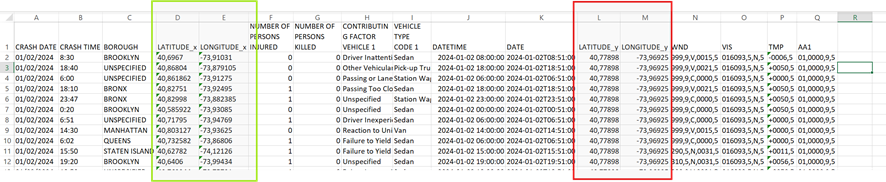

Al inspeccionar visualmente el archivo de Excel, identificamos la causa exacta de la anomalía:

* **Datos correctos (Recuadro Verde):** Las columnas correspondientes a los accidentes contienen las ubicaciones reales y variables de cada accidente. Estos son los datos que **conservaremos**.
* **Datos redundantes (Recuadro Rojo):** Las columnas duplicadas corresponden a la ubicación fija de la estación meteorológica de la **NOAA en Central Park** (cuya latitud y longitud siempre son exactamente las mismas: `40.77898` y `-73.96925`). Al no aportar valor geográfico individual, **deben ser eliminadas**.

> Una vez detectado el origen del error, procedemos con el **borrado** de las columnas de la estación meteorológica y el **renombrado** de las variables de accidentes para restaurar sus nombres originales (`LATITUDE` y `LONGITUDE`).



In [62]:
# Eliminamos las columnas de coordenadas del clima que duplicaban información (_y)
df_final = df_final.drop(columns=['LATITUDE_y', 'LONGITUDE_y'])

# Renombramos las coordenadas reales de los accidentes (_x) para quitarles el sufijo
df_final = df_final.rename(columns={
    'LATITUDE_x': 'LATITUDE',
    'LONGITUDE_x': 'LONGITUDE'
})

# Volvemos a consultar nuestra tabla final mediante el resumen estadístico
print(df_final.describe())

# Verificamos dimensiones
print("Dimensiones de la tabla final:", df_final.shape)

       NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
count              109452.000000             109452.000000   
mean                    0.582210                  0.002768   
min                     0.000000                  0.000000   
25%                     0.000000                  0.000000   
50%                     0.000000                  0.000000   
75%                     1.000000                  0.000000   
max                    17.000000                  4.000000   
std                     0.845608                  0.055089   

       NUMBER OF PEDESTRIANS INJURED  NUMBER OF CYCLIST INJURED  \
count                  109452.000000              109452.000000   
mean                        0.109628                   0.054161   
min                         0.000000                   0.000000   
25%                         0.000000                   0.000000   
50%                         0.000000                   0.000000   
75%                         0.000000   

> Una vez corregidos los nombres y las columnas duplicadas, realizaremos un nuevo control de calidad visual sobre la estructura. Para ello, **exportamos nuevamente el dataframe a un archivo Excel** con el fin de confirmar que la limpieza se ejecutó correctamente.

In [63]:
# Validamos nuevamente
df_final.to_excel("accidentes_clima_2024_final.xlsx", index=False)

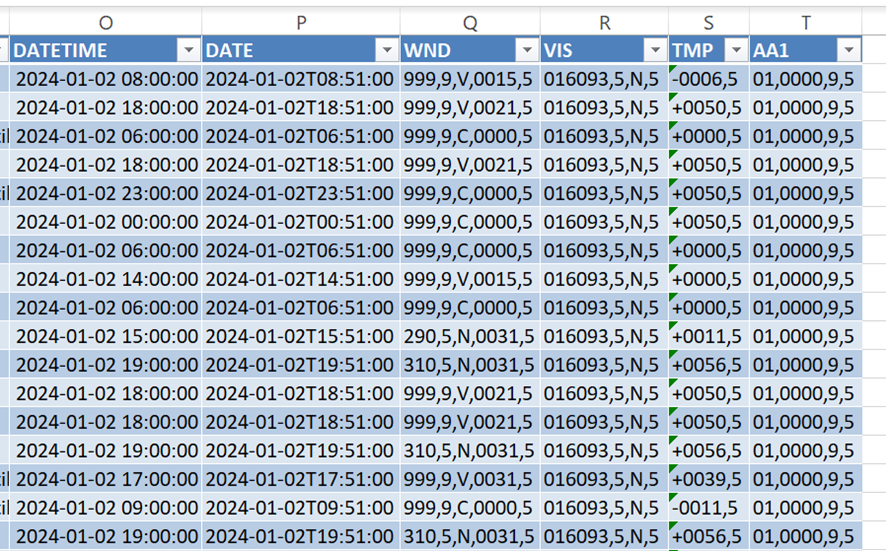

### Análisis del Archivo Exportado: Hallazgos y Propuestas de Solución

Tras revisar el nuevo archivo generado, consolidamos los siguientes hallazgos y estrategias para la transformación de las variables meteorológicas:

1. **`DATETIME` / `DATE`:**
   * **Hallazgo:** Los datos están correctos. Tienen el formato cronológico óptimo que Pandas necesita para operar de forma nativa.
   * **Solución:** Se mantienen sin modificaciones.

2. **`WND` (Viento):**
   * **Hallazgo:** La fuente entrega una cadena codificada (ej. `999,9,V,0015,5` que representa: *dirección, calidad, tipo, velocidad, calidad*). El dato crítico es el cuarto valor (`0015`), que equivale a una velocidad del viento de **1.5 m/s**.
   * **Solución:** Aplicaremos una función para **extraer el cuarto elemento** de la cadena, convertirlo a tipo numérico y dividirlo entre 10.

3. **`VIS` (Visibilidad):**
   * **Hallazgo:** Sigue la misma lógica de codificación (ej. `016093,5,N,5`). Nos interesa el primer valor (`016093`), que equivale a **16,093 metros** (aproximadamente 10 millas, el estándar máximo de visibilidad).
   * **Solución:** Extraeremos la primera sección de la cadena antes de la coma para convertirla en una variable numérica limpia.

4. **`TMP` (Temperatura):**
   * **Hallazgo:** Registra valores con un formato como `+0050,5` (que significa **+5.0 °C**). El valor real se obtiene dividiendo entre 10, mientras que el `,5` es un código interno de calidad del sensor. Registros como `-0006,5` (**-0.6 °C**) son consistentes con el invierno en Nueva York.
   * **Solución:** Extraeremos la parte numérica inicial, la transformaremos a flotante y la **dividiremos entre 10** para obtener la temperatura real en grados Celsius.

5. **`AA1` (Precipitaciones / Lluvia):**
   * **Hallazgo:** La cadena de la NOAA (ej. `01,0000,9,5`) indica el periodo en horas (el primer `01`) y la cantidad de lluvia. El valor `0000` significa **0.0 mm de lluvia** (no llovió). Si este valor cambia, indica presencia de precipitaciones.
   * **Solución:** Extraeremos el segundo segmento de la cadena para aislar los milímetros de lluvia acumulados por hora.

> Luego de este análisis, normalizaremos la información.

Empezamos con AA1 (Precipitación).
Extraemos el valor que nos interesa y lo pasamos de str a numérico y lo dividimos entre 10 para que los datos quden en milímetros (mm)

In [64]:
# ==========================================
# TRANSFORMACIÓN DE VARIABLES DEL CLIMA
# ==========================================

# AA1
# Extraemos el valor de la lluvia (posición 1)
df_final['CANTIDAD_LLUVIA'] = df_final['AA1'].str.split(',').str[1]

# Lo pasamos a número y lo dividimos entre 10 para tener milímetros reales
df_final['CANTIDAD_LLUVIA'] = pd.to_numeric(df_final['CANTIDAD_LLUVIA'], errors='coerce') / 10


Y así con las otras variables:

In [65]:
# Temperatura (TMP): Extraemos la posición 0 y dividimos entre 10 para °C
df_final['TEMPERATURA'] = df_final['TMP'].str.split(',').str[0]
df_final['TEMPERATURA'] = pd.to_numeric(df_final['TEMPERATURA'], errors='coerce') / 10

# Visibilidad (VIS): Extraemos la posición 0 (se queda en metros)
df_final['VISIBILIDAD'] = df_final['VIS'].str.split(',').str[0]
df_final['VISIBILIDAD'] = pd.to_numeric(df_final['VISIBILIDAD'], errors='coerce')

# Viento (WND): Extraemos la velocidad en la posición 3 y dividimos entre 10 para m/s
df_final['VELOCIDAD_VIENTO'] = df_final['WND'].str.split(',').str[3]
df_final['VELOCIDAD_VIENTO'] = pd.to_numeric(df_final['VELOCIDAD_VIENTO'], errors='coerce') / 10

### Validación de las Nuevas Variables Transformadas

Tras aplicar las reglas de normalización, ejecutaremos una fase de control de calidad para asegurar que las transformaciones se realizaron correctamente. Como **buena práctica de ingeniería de datos**, realizaremos dos comprobaciones:

* **Comparación Estructural:** Desplegaremos en la consola una vista comparativa de las columnas originales junto a las nuevas variables procesadas. Esto nos permitirá verificar visualmente que la extracción de texto fue precisa fila por fila.
* **Análisis Estadístico de Control:** Ejecutaremos el método `.describe()` exclusivamente sobre las nuevas variables numéricas. El objetivo es confirmar que los rangos, promedios y valores máximos hagan sentido físico (por ejemplo, que las precipitaciones o temperaturas estén en escalas meteorológicas lógicas).

In [66]:
# Vemos una muestra de 10 filas comparando el ANTES vs DESPUÉS
print("--- ANTES VS DESPUÉS ---")
print(df_final[['AA1', 'CANTIDAD_LLUVIA', 'TMP', 'TEMPERATURA', 'VIS', 'VISIBILIDAD', 'WND', 'VELOCIDAD_VIENTO']].head(10))

--- ANTES VS DESPUÉS ---
           AA1  CANTIDAD_LLUVIA      TMP  TEMPERATURA           VIS  \
0  01,0000,9,5              0.0  -0006,5         -0.6  016093,5,N,5   
1  01,0000,9,5              0.0  +0050,5          5.0  016093,5,N,5   
2  01,0000,9,5              0.0  +0000,5          0.0  016093,5,N,5   
3  01,0000,9,5              0.0  +0050,5          5.0  016093,5,N,5   
4  01,0000,9,5              0.0  +0050,5          5.0  016093,5,N,5   
5  01,0000,9,5              0.0  +0050,5          5.0  016093,5,N,5   
6  01,0000,9,5              0.0  +0000,5          0.0  016093,5,N,5   
7  01,0000,9,5              0.0  +0000,5          0.0  016093,5,N,5   
8  01,0000,9,5              0.0  +0000,5          0.0  016093,5,N,5   
9  01,0000,9,5              0.0  +0011,5          1.1  016093,5,N,5   

   VISIBILIDAD             WND  VELOCIDAD_VIENTO  
0        16093  999,9,V,0015,5               1.5  
1        16093  999,9,V,0021,5               2.1  
2        16093  999,9,C,0000,5          

Comparación estructural preliminar (*Antes vs. Después*) correcta!

In [67]:
# Vemos el resumen estadístico para confirmar que las matemáticas tienen sentido
print("\n--- RESUMEN MATEMÁTICO ---")
print(df_final[['CANTIDAD_LLUVIA', 'TEMPERATURA', 'VISIBILIDAD', 'VELOCIDAD_VIENTO']].describe())


--- RESUMEN MATEMÁTICO ---
       CANTIDAD_LLUVIA    TEMPERATURA    VISIBILIDAD  VELOCIDAD_VIENTO
count     96825.000000  109452.000000  109452.000000     109452.000000
mean          0.328700      33.993968   29719.403391        120.170468
std           1.887523     139.453780  126298.005756        322.004157
min           0.000000     -10.600000     402.000000          0.000000
25%           0.000000       7.000000   12875.000000          1.500000
50%           0.000000      14.400000   16093.000000          2.600000
75%           0.000000      22.200000   16093.000000          4.100000
max          93.000000     999.900000  999999.000000        999.900000


### Diagnóstico del Resumen Estadístico: Detección de Anomalías

El análisis estadístico descriptivo reveló dos anomalías críticas que debemos corregir antes de avanzar:

* **Valores atípicos extremos (`max`):** Se detectaron valores máximos de **999.9** y **999999**.
  * *Causa raíz:* De acuerdo con la documentación de la NOAA, estos números no representan mediciones reales, sino **códigos de error o valores faltantes enmascarados** que el sistema introduce por defecto cuando un sensor falla.
* **Inconsistencia en el volumen de datos (`count`):** La variable `CANTIDAD_LLUVIA` registra únicamente **96,825 filas** completas, en contraste con las **109,452 filas** del total del dataset.

> 🛠️ **Acción correctiva inmediata:** Debemos eliminar este ruído y reemplazar los códigos de error (`999.9`, `999999`) por valores nulos que no afecten nuestros cálculos.

In [68]:
# Reemplazando 999.9 por np.nan  en nuestra columna TEMPERATURA
df_final['TEMPERATURA'] = df_final['TEMPERATURA'].replace(999.9, np.nan)

# Reemplazando 999.9 por np.nan  en nuestra columna VELOCIDAD_VIENTO
df_final['VELOCIDAD_VIENTO'] = df_final['VELOCIDAD_VIENTO'].replace(999.9, np.nan)

# Reemplazando 999999 por np.nan  en nuestra columna VISIBILIDAD
df_final['VISIBILIDAD'] = df_final['VISIBILIDAD'].replace(999999, np.nan)

# Validamos nuevamente
print("\n--- RESUMEN MATEMÁTICO ---")
print(df_final[['CANTIDAD_LLUVIA', 'TEMPERATURA', 'VISIBILIDAD', 'VELOCIDAD_VIENTO']].describe())


--- RESUMEN MATEMÁTICO ---
       CANTIDAD_LLUVIA    TEMPERATURA    VISIBILIDAD  VELOCIDAD_VIENTO
count     96825.000000  107226.000000  107631.000000      96521.000000
mean          0.328700      13.941865   13303.323030          2.312359
std           1.887523       8.964757    4820.741472          1.673696
min           0.000000     -10.600000     402.000000          0.000000
25%           0.000000       6.700000   12875.000000          1.500000
50%           0.000000      13.900000   16093.000000          2.100000
75%           0.000000      21.700000   16093.000000          3.100000
max          93.000000      34.400000   16093.000000         12.900000


Tras aplicar los métodos `.split()` y `.replace()` para remover los códigos de error de la NOAA, realizamos una nueva inspección estadística con los siguientes resultados:

* **Valores Máximos Corregidos (`max`):** El ajuste fue exitoso. Los picos numéricos extremos desaparecieron y ahora muestran valores meteorológicos completamente lógicos y coherentes con el clima de Nueva York.
* **Inconsistencia en el Conteo (`count`):** El número de registros válidos es ahora diferente en todas las variables y ninguno alcanza el total general de **109,452 filas**.
  * *Explicación técnica:* Al reemplazar los códigos de error (`999.9`) por valores nulos legítimos (`NaN`), Pandas los excluye automáticamente del conteo estadístico, dejando al descubierto el volumen real de datos faltantes en cada columna.

> **Acción requerida:** Dado que el dataset está desalineado, debemos definir una estrategia de **imputación de datos faltantes** (completar los huecos) para estandarizar el conteo en todas las variables antes de proceder al análisis definitivo.


### Estrategia de Imputación y Tratamiento de Datos Faltantes

Tras evaluar la naturaleza de los valores nulos (`NaN`) expuestos en el conteo, aplicaremos dos criterios diferenciados según la variable:

#### 1. Variable `CANTIDAD_LLUVIA` (Imputación por Cero)
* **Diagnóstico:** Al analizar las cadenas de la NOAA, identificamos que registros que contenían un `0` solitario o estructuras como `01,0000,9,5` se transformaron en nulos tras el `.split()`. Este comportamiento no se debe a una falla del sensor, sino a que **no hubo precipitaciones (0.0 mm de lluvia)**.
* **Acción:** Reemplazaremos todos los valores `NaN` en esta columna por `0.0`. De este modo, el conteo será matemáticamente correcto y reflejará la realidad climática de los días secos sin alterar las estadísticas.

```python
# Imputación de días sin lluvia
df['CANTIDAD_LLUVIA'] = df['CANTIDAD_LLUVIA'].fillna(0.0)
```

#### 2. Variables de Control Meteorológico (Conservación de `NaN`)
* **Diagnóstico:** Para el resto de las variables climáticas, la variación en el conteo representa un **diagnóstico honesto y real**. Esos valores nulos corresponden a fallas legítimas de los sensores en el momento de la captura.
* **Acción:** **No se deben rellenar**. Intentar adivinar o imputar estos valores con promedios artificiales sesgaría los cálculos estadísticos y arruinaría las métricas finales. Mantenerlos como `NaN` es la práctica más rigurosa para proteger la integridad del análisis.

In [69]:
# Rellenamos los vacíos (NaN) con 0.0 milímetros
df_final['CANTIDAD_LLUVIA'] = df_final['CANTIDAD_LLUVIA'].fillna(0.0)

In [70]:
# Validamos nuevamente
print("\n--- RESUMEN MATEMÁTICO ---")
print(df_final[['CANTIDAD_LLUVIA', 'TEMPERATURA', 'VISIBILIDAD', 'VELOCIDAD_VIENTO']].describe())


--- RESUMEN MATEMÁTICO ---
       CANTIDAD_LLUVIA    TEMPERATURA    VISIBILIDAD  VELOCIDAD_VIENTO
count    109452.000000  107226.000000  107631.000000      96521.000000
mean          0.290780      13.941865   13303.323030          2.312359
std           1.778411       8.964757    4820.741472          1.673696
min           0.000000     -10.600000     402.000000          0.000000
25%           0.000000       6.700000   12875.000000          1.500000
50%           0.000000      13.900000   16093.000000          2.100000
75%           0.000000      21.700000   16093.000000          3.100000
max          93.000000      34.400000   16093.000000         12.900000


In [71]:

# Exportamos nuestra tabla maestra a un archivo de Excel para validar una vez más antes de pasar a la visualización
df_final.to_excel("accidentes_clima_2024.xlsx", index=False)

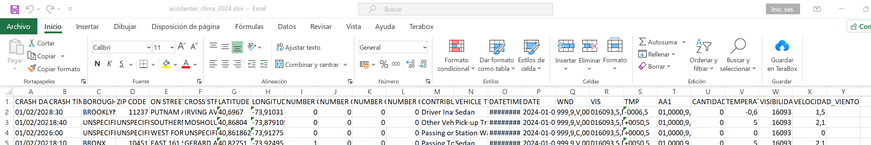

## 📊 Fase de Visualización de Datos (EDA)

Tras validar visualmente en Excel que el conjunto de datos consolidado está completamente limpio y corregido, iniciamos la fase de exploración gráfica para extraer los primeros *insights* del negocio.

### 1. Accidentes en Días Secos vs. Días Lluviosos en NY (2024)

El primer objetivo es analizar el impacto de las precipitaciones en la seguridad vial. Para lograrlo, segmentaremos el universo total de **109,452 registros** en dos grandes grupos condicionales:

* **Suelo Seco:** Total de accidentes ocurridos cuando la variable `CANTIDAD_LLUVIA` es igual a `0.0` mm.
* **Con Lluvia:** Total de accidentes registrados cuando la variable `CANTIDAD_LLUVIA` es estrictamente mayor a `0.0` mm.

#### Implementación del Filtro en Pandas

Para realizar esta agrupación y conteo en nuestro cuaderno de trabajo, aplicamos la siguiente lógica de filtrado:


Total accidentes con suelo seco: 93168
Total accidentes con suelo mojado: 16284


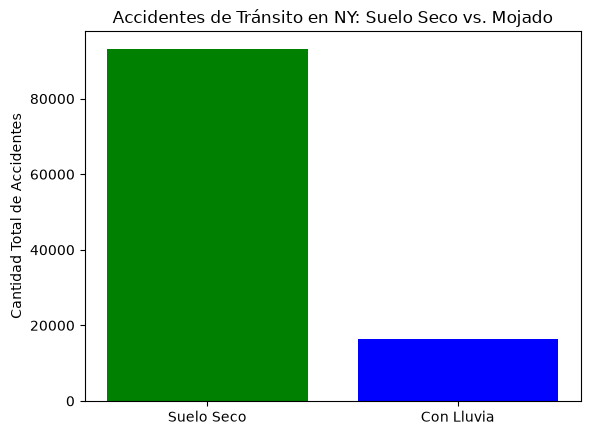

In [72]:
# ==========================================
#   ANÁLISIS Y VISUALIZACIÓN
# ==========================================

# ====================
# ACCIDENTES EN DÍAS SECOS VS DÍAS LLUVIOSOS
# ====================
# Filtramos los accidentes con suelo seco (lluvia exactamente igual a cero)
accidentes_seco = df_final[df_final['CANTIDAD_LLUVIA'] == 0.0]

# Filtramos los accidentes con lluvia (lluvia mayor a cero)
accidentes_lluvia = df_final[df_final['CANTIDAD_LLUVIA'] > 0.0]

# Contamos cuántos accidentes hay en cada una usando len()
total_seco = len(accidentes_seco)
total_lluvia = len(accidentes_lluvia)

# Conocemos los valores 
print("Total accidentes con suelo seco:", total_seco)
print("Total accidentes con suelo mojado:", total_lluvia)

# Preparamos las listas para el gráfico
categorias = ['Suelo Seco', 'Con Lluvia']
totales = [total_seco, total_lluvia]

# Dibujamos el gráfico de barras
plt.bar(categorias, totales, color=['green', 'blue']) # Colores para diferenciar
plt.title('Accidentes de Tránsito en NY: Suelo Seco vs. Mojado')
plt.ylabel('Cantidad Total de Accidentes')

# Graficamos
plt.show()

### Observaciones y Análisis del Gráfico

Tras analizar la distribución de los accidentes según las condiciones climáticas, consolidamos las siguientes conclusiones:

* **Consistencia del Volumen:** La suma de ambos segmentos (accidentes en suelo seco + accidentes con lluvia) equivale exactamente a **109,452 registros**, lo que valida que no perdimos información durante el filtrado.
* **Sesgo de Frecuencia Base:** El gráfico muestra una cantidad significativamente mayor de accidentes con el suelo seco durante el año **2024**. Sin embargo, la verdadera explicación lógica detrás de este comportamiento es que **existen muchos más días secos que días lluviosos en el año**. 

> 💡 **Conclusión Estadística:** El volumen bruto de accidentes no significa que conducir bajo la lluvia sea más seguro; simplemente refleja la distribución natural del clima en Nueva York. 


### 2. Distribución de Accidentes en NY Mes a Mes (2024)

Para analizar la estacionalidad de los siniestros a lo largo del año, necesitamos realizar una agregación temporal. El primer paso es asegurarnos de que Pandas interprete la columna `CRASH DATE` como objetos de fecha reales (`datetime`) y no como cadenas de texto (`string`).

* **Herramienta utilizada:** Aplicaremos la función `pd.to_datetime()` para realizar la conversión de tipo de dato de forma masiva.
* **Extracción del periodo:** Una vez transformado el formato, extraeremos el componente numérico del mes para agrupar los **109,452 registros** y graficar la tendencia mensual.

In [73]:
# ====================
# ACCIDENTES DURANTE TODO EL AÑO MES A MES
# ====================
# Transformamos toda la columna CRASH DATE a formato de fecha
df_final['CRASH DATE'] = pd.to_datetime(df_final['CRASH DATE'])

# Extraemos solo el número del mes y lo guardamos en una nueva columna
df_final['MES'] = df_final['CRASH DATE'].dt.month

# Contamos los accidentes por mes y los ordenamos del 1 al 12
accidentes_por_mes = df_final['MES'].value_counts().sort_index()

# Conocemos los valores 
print("Total mes a mes:", accidentes_por_mes)

Total mes a mes: MES
1     10348
2      7797
3     10356
4      8734
5     10868
6      8645
7      8410
8      8856
9      8253
10     7618
11     8851
12    10716
Name: count, dtype: int64


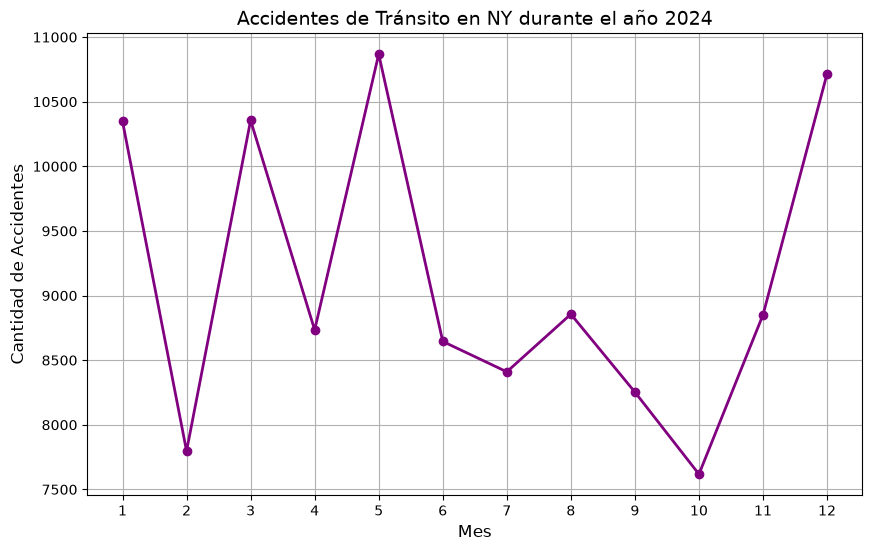

In [74]:
# Dibujamos el gráfico de líneas
plt.figure(figsize=(10, 6))

# Usamos marker='o' para poner un puntito en cada mes
plt.plot(accidentes_por_mes.index, accidentes_por_mes.values, marker='o', color='purple', linewidth=2)

plt.title('Accidentes de Tránsito en NY durante el año 2024', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Accidentes', fontsize=12)

# Esto asegura que veamos los números del 1 al 12 en la barra de abajo y tengamos cuadrícula
plt.xticks(range(1, 13)) 
plt.grid(True)

plt.show()

### Análisis de la Tendencia Mensual

A partir del gráfico generado, se identificaron los siguientes patrones en el comportamiento de los siniestros a lo largo del año **2024**:

* **Picos de Alta Siniestralidad:** El mes de **mayo** registra el punto más alto del año con **10,868 accidentes**. Asimismo, la gráfica revela elevaciones importantes al inicio del año (entre enero y marzo) y un repunte significativo hacia el cierre en **diciembre** (**10,716 accidentes**).
* **Valles de Baja Siniestralidad:** El mes de **octubre** se consolida como el periodo con menor actividad vial, registrando un mínimo de **7,618 choques**. Por su parte, meses como febrero y julio también muestran caídas notorias en el volumen total de accidentes.

> **Conclusión Temporal:** Los accidentes automovilísticos en Nueva York no se distribuyen de forma uniforme a lo largo del año. La concentración de siniestros en primavera (mayo) y durante las festividades de fin de año (diciembre) coincide directamente con periodos de mayor movimeinto económico, turismo, celebraciones y un incremento masivo en el flujo peatonal y vehicular de la ciudad.


### 3. Distribución de Accidentes según la Visibilidad

Dado que contamos con un gran volumen de registros continuos para la visibilidad, utilizaremos un **histograma** como herramienta de análisis. Este gráfico nos permite agrupar automáticamente los datos en rangos uniformes (por ejemplo: de 0 a 2,000 m, de 2,000 a 4,000 m, etc.) para identificar visualmente en qué intervalos se concentra el mayor volumen de siniestros.

* **Objetivo del gráfico:** Evaluar si las condiciones de baja visibilidad (como niebla o lluvia densa) se traducen en picos de accidentalidad, o si la distribución sigue la tendencia general del clima.
* **Métrica utilizada:** Variable `VIS` normalizada (expresada en metros).

#### Configuración del Histograma en Python

Para generar esta distribución agrupando los datos en intervalos óptimos, podemos utilizaremos 20 grupos con **bins=20**


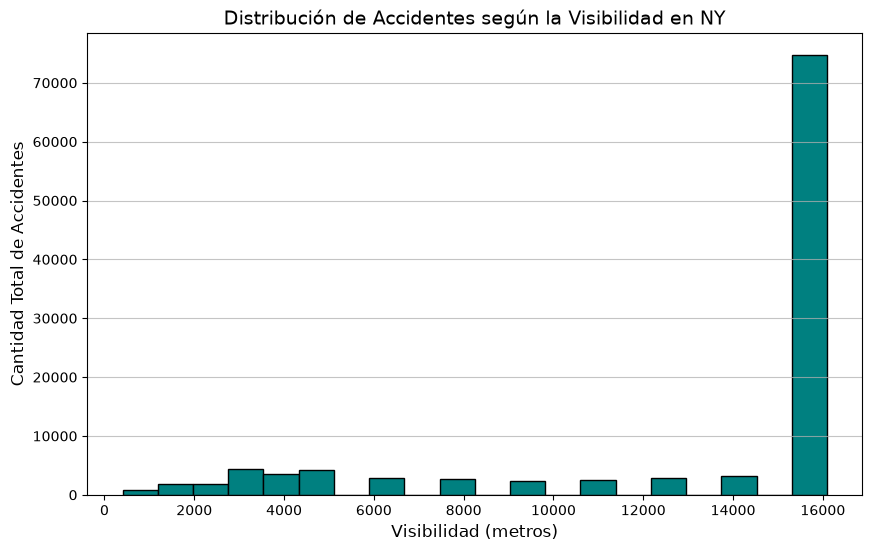

In [75]:
# ==========================================
# DISTRIBUCIÓN DE ACCIDENTES SEGÚN LA VISIBILIDAD
# ==========================================

# Extraemos la columna de visibilidad (y quitamos posibles valores vacíos por seguridad)
visibilidad_datos = df_final['VISIBILIDAD'].dropna()

# Dibujamos el histograma
plt.figure(figsize=(10, 6))

# Para que tengamos 20 grupos usamos bins=20
plt.hist(visibilidad_datos, bins=20, color='teal', edgecolor='black')

plt.title('Distribución de Accidentes según la Visibilidad en NY', fontsize=14)
plt.xlabel('Visibilidad (metros)', fontsize=12)
plt.ylabel('Cantidad Total de Accidentes', fontsize=12)
plt.grid(axis='y', alpha=0.75)

# Graficamos
plt.show()

### Análisis

La inspección del histograma revela un comportamiento asimétrico muy marcado en los datos:

* **Concentración Masiva Extrema:** La gráfica muestra un pico sumamente alto que supera los **70,000 accidentes** concentrados exclusivamente en la barra de los **16,000 metros** (visibilidad estándar perfectamente despejada).
* **Baja Visibilidad:** Por el contrario, los intervalos que representan condiciones de niebla, tormentas o visibilidad reducida registran un volumen de accidentes notablemente bajo.

> **Interpretación:** Al igual que con el suelo seco, este resultado **no significa que la buena visibilidad provoque choques**. La explicación real es que la inmensa mayoría de los días en Nueva York gozan de un clima despejado. Bajo estas condiciones óptimas, el flujo vehicular opera al máximo de su capacidad, lo que estadísticamente eleva la probabilidad absoluta de que ocurra un siniestro debido al volumen de tráfico circulando.


### 4. Análisis de las Principales Causas de Accidentes

Para entender qué factores detonan la accidentalidad vial en Nueva York, analizaremos la variable categórica correspondiente a las causas registradas por los oficiales en el lugar del hecho. Dado que existen decenas de motivos diferentes, nos enfocaremos en **identificar y graficar el "Top 10" de las causas más frecuentes**.

* **Herramienta recomendada:** Utilizaremos un **gráfico de barras horizontales** (`plt.barh`), ya que facilita la lectura directa de los nombres largos de cada causa en el eje vertical.
* **Métrica utilizada:** Conteo de frecuencias de la variable `CONTRIBUTING FACTOR VEHICLE 1` (excluíremos registros genéricos como "Unspecified" para mayor claridad).

#### Código de Extracción y Filtrado en Pandas

Para aislar únicamente los 10 factores con mayor impacto en el dataset, ejecutamos la siguiente instrucción:


In [76]:
# ==========================================
# CAUSAS DE ACCIDENTES
# ==========================================

# Contamos todas las causas de la columna
causas = df_final['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

# Quitamos la categoría 'Unspecified' para ver los motivos reales que si aportan valor
causas_reales = causas[causas.index != 'Unspecified']

# 10 causas principales
print("\n--- TOP 10 CAUSAS DE ACCIDENTES ---")
print(causas_reales.head(10))



--- TOP 10 CAUSAS DE ACCIDENTES ---
CONTRIBUTING FACTOR VEHICLE 1
Driver Inattention/Distraction    26530
Failure to Yield Right-of-Way      7751
Following Too Closely              6162
Passing or Lane Usage Improper     4394
Unsafe Speed                       4001
Passing Too Closely                3543
Other Vehicular                    3415
Backing Unsafely                   3365
Traffic Control Disregarded        3147
Turning Improperly                 2541
Name: count, dtype: int64


### Conclusión del Análisis de Causas: El Factor Humano

Los resultados del ranking revelan un patrón definitivo sobre el origen de los siniestros viales en Nueva York:

* **Causa Predominante:** La **distracción del conductor** (*Driver Inattention/Distraction*) se consolida como la causa número uno con una cifra crítica de **26,530 accidentes** registrados.
* **Impacto Relativo:** Este volumen supera por un margen amplio a cualquier otra categoría o falla mecánica dentro del conjunto de datos.

> **Insight Principal:** Los datos demuestran de manera contundente que **la mayor causa de accidentalidad en la ciudad no está relacionada con el clima, sino con el comportamiento de las personas al volante**. Las condiciones meteorológicas adversas (como la lluvia o la baja visibilidad) pasan a un segundo plano frente a la imprudencia y la falta de atención de los conductores como el verdadero factor de riesgo crítico.


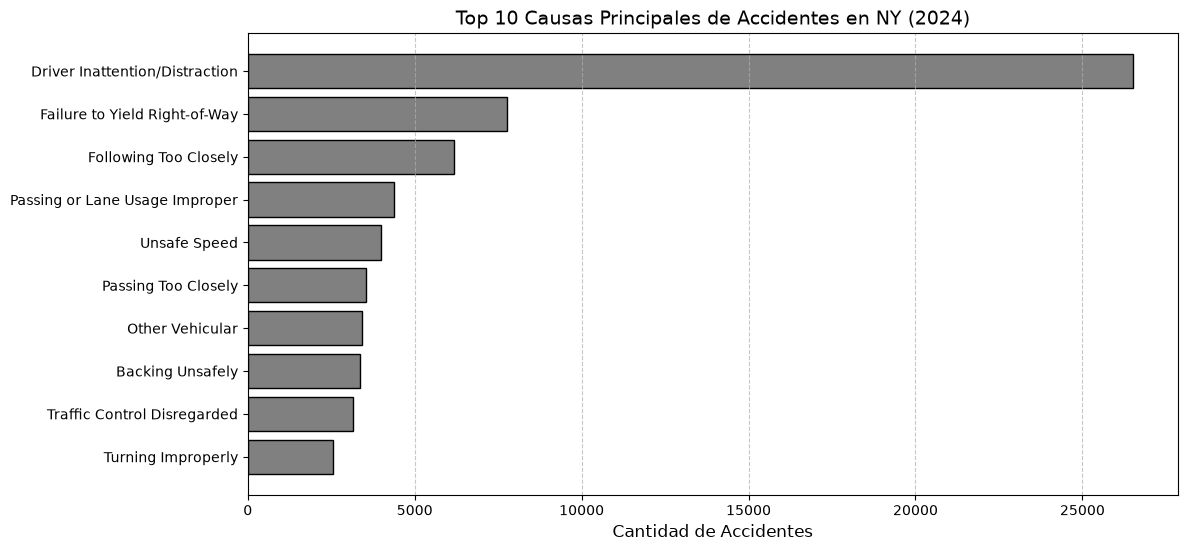

In [77]:
# Guardamos las causas
top_10_causas = causas_reales.head(10)

# Invertimos la lista para que la causa #1 aparezca arriba
top_10_causas = top_10_causas.iloc[::-1]

# Graficamos horizontalmente barh()
plt.figure(figsize=(12, 6))
plt.barh(top_10_causas.index, top_10_causas.values, color='gray', edgecolor='black')

plt.title('Top 10 Causas Principales de Accidentes en NY (2024)', fontsize=14)
plt.xlabel('Cantidad de Accidentes', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


### Discusión de Hallazgos y Comportamiento Vial

Al profundizar en el análisis de los factores contribuyentes, consolidamos las siguientes observaciones críticas sobre la seguridad vial en Nueva York:

* **Predominio del Factor Humano:** La **distracción al volante** es la causa absoluta e indiscutible de accidentes en la ciudad. Se infiere que la integración masiva de la tecnología en el vehículo (como el uso de teléfonos móviles y sistemas de navegación) es uno de los principales catalizadores de estas distracciones, superando por un margen muy amplio a cualquier variable ambiental.
* **Infracciones de Tránsito Concurrentes:** El resto de las causas principales identificadas en el ranking corresponden también a conductas negligentes y errores humanos explícitos. Entre ellos destacan el **uso indebido del carril**, el **exceso de velocidad** y el incumplimiento de las normas de tránsito.

> **Conclusión General del Estudio**
> Los datos consolidados confirman que **el clima no actúa como una causa directa en el volumen general de accidentes**. Las condiciones meteorológicas adversas representan un entorno modificador, pero las decisiones de riesgo, la imprudencia y los errores operativos de los conductores son las verdaderas razones de la siniestralidad en la ciudad de Nueva York.

## Análisis de Severidad: Causas vs. Impacto en Víctimas

Para profundizar en el análisis, realizaremos un cruce entre la variable categórica de causas (`CONTRIBUTING FACTOR VEHICLE 1`) y la variable numérica de afectación (`NUMBER OF PERSONS INJURED`).

### Justificación Metodológica: Volumen vs. Severidad

Si evaluamos el impacto basándonos únicamente en el conteo total de accidentes, la distracción del conductor distorsionará los resultados debido a su altísima frecuencia (más de 26,000 registros). Para determinar qué causa es **estadísticamente más peligrosa**, es indispensable calcular el **promedio (*mean*) de heridos por accidente** para cada factor.

* **El objetivo:** Evaluar si infracciones específicas (como el *exceso de velocidad*) registran una tasa de lesionados por evento significativamente mayor que las distracciones cotidianas.
* **Técnica aplicada:** Agruparemos el dataset por causa principal y calcularemos la media aritmética de personas heridas.

In [78]:
# ==========================================
# ANÁLISIS ESTADÍSTICO DE GRAVEDAD
# ==========================================

# Por seguridad, rellenamos los valores vacíos de heridos con 0
df_final['NUMBER OF PERSONS INJURED'] = df_final['NUMBER OF PERSONS INJURED'].fillna(0)

# Filtramos el ruido ('Unspecified') para enfocarnos en causas reales
df_causas = df_final[df_final['CONTRIBUTING FACTOR VEHICLE 1'] != 'Unspecified']

# Agrupamos por causa y calculamos estadísticamentes: cantidad de choques y promedio de heridos
estadisticas = df_causas.groupby('CONTRIBUTING FACTOR VEHICLE 1')['NUMBER OF PERSONS INJURED'].agg(['count', 'mean'])

# Renombramos para mayor claridad
estadisticas.columns = ['Total_Accidentes', 'Promedio_Heridos_por_Choque']

# Filtramos causas con más de 1,000 accidentes para que el dato sea confiable
causas_frecuentes = estadisticas[estadisticas['Total_Accidentes'] > 1000]

# Ordenamos para ver cuál tiene el promedio de heridos MÁS ALTO
top_gravedad = causas_frecuentes.sort_values(by='Promedio_Heridos_por_Choque', ascending=False)

print("\n--- CAUSAS MÁS PELIGROSAS (PROMEDIO DE HERIDOS) ---")
print(top_gravedad.head(5))



--- CAUSAS MÁS PELIGROSAS (PROMEDIO DE HERIDOS) ---
                                                    Total_Accidentes  \
CONTRIBUTING FACTOR VEHICLE 1                                          
Traffic Control Disregarded                                     3147   
Pedestrian/Bicyclist/Other Pedestrian Error/Con...              1281   
Failure to Yield Right-of-Way                                   7751   
Unsafe Speed                                                    4001   
Following Too Closely                                           6162   

                                                    Promedio_Heridos_por_Choque  
CONTRIBUTING FACTOR VEHICLE 1                                                    
Traffic Control Disregarded                                            0.928821  
Pedestrian/Bicyclist/Other Pedestrian Error/Con...                     0.879781  
Failure to Yield Right-of-Way                                          0.873178  
Unsafe Speed                    

### Análisis del Top 5 de Severidad: Cantidad vs. Gravedad

Al calcular el promedio de heridos por accidente, la perspectiva de la siniestralidad vial en Nueva York cambia radicalmente. Los hallazgos estadísticos demuestran lo siguiente:

| Variable / Comportamiento | Frecuencia (Volumen) | Severidad (Promedio de Heridos) | Impacto Real |
| :--- | :--- | :--- | :--- |
| **`DRIVER INATTENTION/DISTRACTION`** | Alta (Más de 26,000 casos) | Muy baja (No entra al Top 5) | Colisiones menores a baja velocidad debido al tráfico lento. |
| **`TRAFFIC CONTROL DISREGARDED`** | Moderada | **Alta (0.928821 heridos por evento)** | Choques de alta energía con un herido casi garantizado por impacto. |

#### Observaciones Analíticas
* **La naturaleza de la distracción:** El hecho de que la distracción al volante desaparezca por completo del *Top 5 de peligrosidad* confirma que la inmensa mayoría de esos 26,000 incidentes son colisiones menores (como alcances traseros en semáforos), típicas de una ciudad densamente transitada como Nueva York.
* **El peligro de ignorar las señales:** Por el contrario, no respetar el control de tráfico (`TRAFFIC CONTROL DISREGARDED`) registra una media cercana a **1 herido por choque (0.92)**. Este dato posee una sólida lógica física: cuando un conductor ignora un semáforo en rojo o una señal de alto, suele acelerar a fondo para adelantarse al cambio de luces, detonando impactos laterales u ortogonales de alta energía.

> 🏁 **Conclusión General del Proyecto**
> Este estudio demuestra de forma contundente que **nunca se debe confundir la cantidad con la gravedad**. Mientras que el uso de la tecnología y la distracción humana generan el mayor volumen bruto de incidentes viales, el **irrespetar las señales de tránsito es la verdadera conducta responsable de los heridos y la violencia vial** en la ciudad de Nueva York. Las políticas de seguridad pública deben priorizar la fiscalización de intersecciones por encima de los factores ambientales.


In [79]:
# ==========================================
#   DASHBOARD
# ==========================================

# Para realizar un dashboard operativo lo haremos con Power BI, así que para esto realizamos la exportación de nuestros datos limpios a .csv

# Guardamos los datos limpios para usarlos en Power BI
df_final.to_csv('accidentes_ny_limpio.csv', index=False)

A partir de aquí pasamos a PowerBI, y los apuntes se mostrarán en un pdf llamado `MemoriasPowerBI.pdf`, el cual estará adjunto en el git según la estructura planteada en el Readme.